In [5]:
# Installation automatique des dépendances requises dans le noyau Jupyter actuel
%pip install -r ../requirements.txt

Note: you may need to restart the kernel to use updated packages.


# 🧪 Étape 6 : Évaluation Métrique & Robustesse (Squelette Étudiant)

Cette étape correspond au sixième chapitre du cours. L'objectif est de mettre en place un protocole d'évaluation rigoureux (splits d'évaluation adaptés) et de calculer les métriques clés de performance pour valider scientifiquement la qualité de vos modèles.

### 1. Préparation de l'environnement

In [6]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

sys.path.append(os.path.abspath('..'))
print("Librairies prêtes pour l'évaluation des modèles !")

Librairies prêtes pour l'évaluation des modèles !


### 2. Évaluation du modèle Tabulaire — Random Forest

#### Pourquoi évaluer un modèle ?

Après l'entraînement, il est indispensable de mesurer **à quel point le modèle se trompe** sur des données qu'il n'a jamais vues (le jeu de test = 20% des données). On ré-entraîne ici le même Random Forest qu'en étape 5, puis on calcule trois métriques complémentaires :

| Métrique | Formule | Interprétation |
|----------|---------|----------------|
| **MAE** (Mean Absolute Error) | $\frac{1}{n}\sum|y_i - \hat{y}_i|$ | Erreur moyenne en roupies — facile à comprendre |
| **RMSE** (Root Mean Square Error) | $\sqrt{\frac{1}{n}\sum(y_i - \hat{y}_i)^2}$ | Pénalise davantage les grosses erreurs |
| **R²** (coefficient de détermination) | $1 - \frac{SS_{res}}{SS_{tot}}$ | % de la variance du prix expliqué par le modèle (1 = parfait, 0 = nul) |

#### Comment interpréter les résultats ?

- **MAE** : si MAE = 15 000 ₹, le modèle se trompe en moyenne de ±15 000 ₹ sur le prix d'un laptop
- **RMSE** : toujours ≥ MAE ; un RMSE très supérieur à la MAE révèle quelques grosses erreurs
- **R²** : un R² > 0.85 est généralement considéré comme **très bon** pour de la régression de prix

#### Visualisation

Le graphique **Prédictions vs Prix réels** permet d'évaluer visuellement la qualité :
- Les points proches de la droite rouge (y = x) = prédictions précises
- Les points éloignés = erreurs importantes (sur- ou sous-estimations du prix)


=== Métriques d'évaluation sur le jeu de test ===
MAE  (erreur absolue moyenne) : 8,690 ₹
RMSE (racine de l'erreur MSE) : 15,260 ₹
R²   (coefficient de déterm.) : 0.839


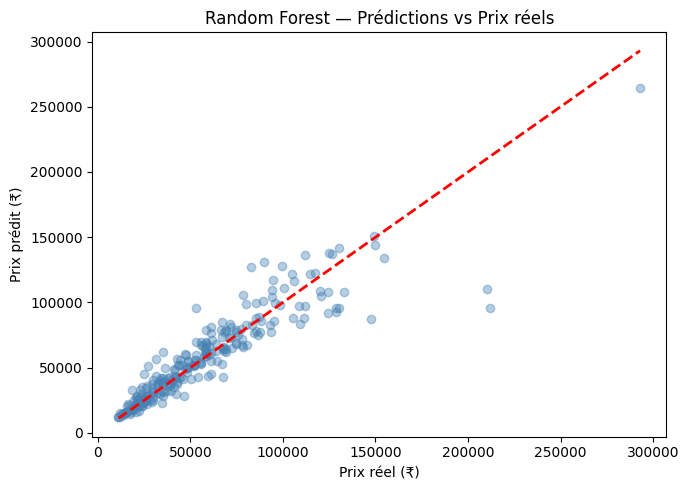

In [7]:
# Chargement et préparation des données (même pipeline que 05_modelisation)
df = pd.read_csv('../data/processed/cleaned_data_sample.csv')

df["Inches"]           = pd.to_numeric(df["Inches"],           errors="coerce")
df["Res_Width"]        = pd.to_numeric(df["Res_Width"],        errors="coerce")
df["Res_Height"]       = pd.to_numeric(df["Res_Height"],       errors="coerce")
df["Cpu_Frequence_GHz"]= pd.to_numeric(df["Cpu_Frequence_GHz"],errors="coerce")

le = LabelEncoder()
df["Company_enc"]  = le.fit_transform(df["Company"].astype(str))
df["TypeName_enc"] = le.fit_transform(df["TypeName"].astype(str))
df["OpSys_enc"]    = le.fit_transform(df["OpSys"].astype(str))
df["Cpu_Gamme_enc"]= le.fit_transform(df["Cpu_Gamme"].astype(str))

features = [
    "Inches", "Ram", "Cpu_Frequence_GHz", "weight_kg",
    "total_memory_gb", "Res_Width", "Res_Height",
    "has_ssd", "has_hdd", "has_intel_gpu", "has_nvidia_gpu", "has_amd_gpu",
    "Is_IPS", "Company_enc", "TypeName_enc", "OpSys_enc", "Cpu_Gamme_enc"
]
target = "Price"

X = df[features].fillna(0)
y = df[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Entraînement du modèle Random Forest
model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Calcul des métriques d'évaluation
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print("=== Métriques d'évaluation sur le jeu de test ===")
print(f"MAE  (erreur absolue moyenne) : {mae:,.0f} ₹")
print(f"RMSE (racine de l'erreur MSE) : {rmse:,.0f} ₹")
print(f"R²   (coefficient de déterm.) : {r2:.3f}")

# Visualisation : Prédictions vs Prix réels
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred, alpha=0.4, color='steelblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Prix réel (₹)")
plt.ylabel("Prix prédit (₹)")
plt.title("Random Forest — Prédictions vs Prix réels")
plt.tight_layout()
plt.show()

### 3. Protocole de Validation Croisée (K-Fold)

Une seule évaluation sur un jeu de test fixe peut être biaisée selon le découpage choisi. La **validation croisée K-Fold** permet de valider la robustesse du modèle sur l'ensemble du dataset :

- Le jeu de données est découpé en **5 parties (folds)** égales
- Le modèle est entraîné 5 fois : à chaque itération, 4 folds servent à l'entraînement et 1 fold au test
- On calcule la moyenne et l'écart-type des métriques sur les 5 itérations

**Interprétation :** un R² stable entre les folds (faible écart-type) indique un modèle **robuste**, sans surapprentissage (overfitting).

In [8]:
# Validation croisée K-Fold (5 folds) — évalue la robustesse du modèle
kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(model, X, y, cv=kf, scoring='r2')
cv_mae    = -cross_val_score(model, X, y, cv=kf, scoring='neg_mean_absolute_error')

print("=== Validation croisée K-Fold (5 folds) ===")
print(f"R²  par fold : {[f'{s:.3f}' for s in cv_scores]}")
print(f"R²  moyen    : {cv_scores.mean():.3f} (+/- {cv_scores.std():.3f})")
print(f"MAE moyenne  : {cv_mae.mean():,.0f} ₹ (+/- {cv_mae.std():,.0f} ₹)")
print()
print("Interprétation : un R² stable entre les folds indique un modèle robuste sans surapprentissage.")

=== Validation croisée K-Fold (5 folds) ===
R²  par fold : ['0.840', '0.843', '0.833', '0.810', '0.797']
R²  moyen    : 0.825 (+/- 0.018)
MAE moyenne  : 9,775 ₹ (+/- 786 ₹)

Interprétation : un R² stable entre les folds indique un modèle robuste sans surapprentissage.
